# 📊 ImmoEliza Data Analysis Notebook - Team Horse - Soo

This is a notebook to conduct the individual data analysis of project ImmoEliza.

"Now that the data has been both collected and cleaned, let's move on to the analysis. Data Analysis focuses on what IS, and hopes to give insights to the state of the dataset and relationships within it. Each team member should put forward at least 2 visuals.

You must be able to answer following questions (with a vizualization if appropriate):

- How many observations and features/columns do you have?  
- What is the proportion of missing values per column?  
- Which variables would you delete and why?  
- What variables are most subject to outliers?  
- How many qualitative and quantitative variables are there? What are appropiate visuals for quantitative vs qualitative data? What are appropiate measures for correlations when dealing with qualitative and quantitative variables?  
- What is the correlation between the variables and the price? Why do you think some variables are more correlated than others?  
- How are the variables themselves correlated to each other? Can you find groups of variables that are correlated together?  
- How are the number of properties distributed according to their surface?  
- Which five variables do you consider the most important and why?  
- What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? (in terms of price per m², average price, and median price)  

This is a non-exhaustive list of possible questions. Try to make a maximum number of interpretations from the dataset. Bonus points for creative and out-of-the-box insights.

Use tools such as matplotlib, seaborn, plotly, or [insert whatever visualization tool you find useful]...

Do your analysis in notebooks. No real need for scripting in this case, you'll want to have your hands free to experiment and explore the data in many directions. Writing functions for code you reuse is still a good idea, don't lose track of your good habits. Don't make it too messy though, your results should be reproducible and Immo Eliza's CEO might ask to rerun an analysis with a slight change :-)"

In [7]:
# Basic setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df_rent = pd.read_csv("../Data/Clean/RentCleanForAnalysis.csv")
df_sale = pd.read_csv("../Data/Clean/SaleCleanForAnalysis.csv")

### How many observations and features/columns do you have?

Observations = the number of rows  
Features = the number of columns

In [8]:
print("Rent CSV shape: ", df_rent.shape)
print("Sale CSV shape: ", df_sale.shape)

Rent CSV shape:  (3797, 26)
Sale CSV shape:  (9712, 26)


### What is the proportion of missing values per column?

In [9]:
# For rent 
# missing_pct_rent = (df_rent.isna().mean() * 100).round(2) # mean of a bool col = true / number of rows
# missing_pct_sorted = missing_pct_rent.sort_values(ascending=False)
# missing_table = missing_pct_sorted.to_frame("Missing %")
# display(missing_table.style.format("{:.2f}%"))

# sns.barplot(
# 	x=missing_pct_sorted.values,
# 	y=missing_pct_sorted.index,
# )
# plt.show()

In [10]:
# Missing values / Rent / Appartment
missing_rent_apt = (df_rent[df_rent["property_type"] == "Appartment"].isna().mean() * 100).round(2)
missing_rent_apt_sorted = missing_rent_apt.sort_values(ascending=False)
missing_table_rent_apt = missing_rent_apt_sorted.to_frame("Missing %")
display(missing_table_rent_apt.style.format("{:.2f}%"))

AttributeError: The '.style' accessor requires jinja2

In [ ]:
# Missing values / Rent / House
missing_rent_hse = (df_rent[df_rent["property_type"] == "House"].isna().mean() * 100).round(2)
missing_rent_hse_sorted = missing_rent_hse.sort_values(ascending=False)
missing_table_rent_hse = missing_rent_hse_sorted.to_frame("Missing %")
display(missing_table_rent_hse.style.format("{:.2f}%"))

,Missing %
balcony,89.50%
swimming_pool,83.52%
energy_consumption,73.36%
garden,68.85%
terrace,65.91%
garage,65.35%
date_of_construction,60.84%
land_surface,54.63%
availability,41.08%
elevator,33.18%


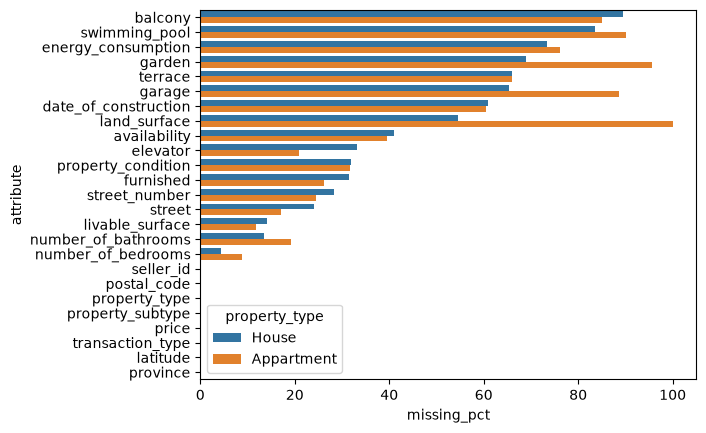

In [ ]:
# Visualisation for missing values in Rent
rent_apt = (
	df_rent[df_rent["property_type"] == "Appartment"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
rent_apt.columns = ["attribute", "missing_pct"]
rent_apt["property_type"] = "Appartment"
rent_apt = rent_apt.sort_values("missing_pct", ascending=False)

rent_house = (
	df_rent[df_rent["property_type"] == "House"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
rent_house.columns = ["attribute", "missing_pct"]
rent_house["property_type"] = "House"
rent_house = rent_house.sort_values("missing_pct", ascending=False)

# Stack them together
rent_combined = pd.concat([rent_house, rent_apt], ignore_index=True)

sns.barplot(
	data=rent_combined,
	x="missing_pct",
	y="attribute",
	hue="property_type",
	orient="h"
)

plt.show()


In [ ]:
# # For sale
# missing_pct_sale = (df_sale.isna().mean() * 100).round(2)
# missing_pct_sorted = missing_pct_sale.sort_values(ascending=False)
# missing_table = missing_pct_sorted.to_frame("Missing %")
# display(missing_table.style.format("{:.2f}%"))

# sns.barplot(
# 	x=missing_pct_sorted.values,
# 	y=missing_pct_sorted.index,
# )
# plt.show()

In [ ]:
# Missing values / Sale / Appartment
missing_sale_apt = (df_sale[df_sale["property_type"] == "Appartment"].isna().mean() * 100).round(2)
missing_sale_apt_sorted = missing_sale_apt.sort_values(ascending=False)
missing_table_sale_apt = missing_sale_apt_sorted.to_frame("Missing %")
display(missing_table_sale_apt.style.format("{:.2f}%"))

,Missing %
land_surface,100.00%
garden,93.89%
swimming_pool,89.77%
balcony,88.05%
garage,81.79%
energy_consumption,79.15%
availability,51.23%
terrace,51.20%
furnished,37.50%
date_of_construction,30.22%


In [ ]:
# Missing values / Sale / House
missing_sale_hse = (df_sale[df_sale["property_type"] == "House"].isna().mean() * 100).round(2)
missing_sale_hse_sorted = missing_sale_hse.sort_values(ascending=False)
missing_table_sale_hse = missing_sale_hse_sorted.to_frame("Missing %")
display(missing_table_sale_hse.style.format("{:.2f}%"))

,Missing %
balcony,90.24%
swimming_pool,84.37%
energy_consumption,72.99%
terrace,67.77%
garden,65.72%
garage,55.08%
availability,42.12%
furnished,39.30%
date_of_construction,37.92%
elevator,31.94%


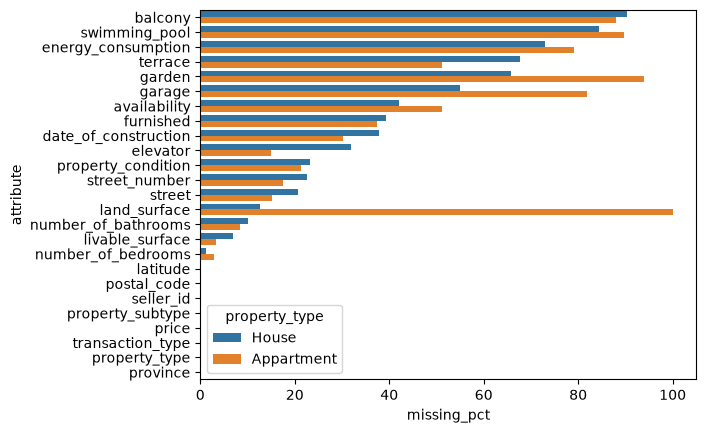

In [ ]:
# Visualisation for Sale

# Visualisation for missing values in Sale
sale_apt = (
	df_sale[df_sale["property_type"] == "Appartment"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
sale_apt.columns = ["attribute", "missing_pct"]
sale_apt["property_type"] = "Appartment"
sale_apt = sale_apt.sort_values("missing_pct", ascending=False)

sale_house = (
	df_sale[df_sale["property_type"] == "House"]
	.isna()
	.mean()
	.mul(100)
	.reset_index()
)
sale_house.columns = ["attribute", "missing_pct"]
sale_house["property_type"] = "House"
sale_house = sale_house.sort_values("missing_pct", ascending=False)

# Stack them together
sale_combined = pd.concat([sale_house, sale_apt], ignore_index=True)

sns.barplot(
	data=sale_combined,
	x="missing_pct",
	y="attribute",
	hue="property_type",
	orient="h"
)

plt.show()


### Mapping Belgium

In [ ]:
df_sale_house = df_sale[df_sale["property_type"] == "House"].copy()
df_sale_house["price_per_m2"] = df_sale_house["price"] / df_sale_house["livable_surface"]

df_sale_apt = df_sale[df_sale["property_type"] == "Appartment"].copy()
df_sale_apt["price_per_m2"] = df_sale_apt["price"] / df_sale_apt["livable_surface"]

combined_price_m2 = pd.concat([
    df_sale_house["price_per_m2"],
    df_sale_apt["price_per_m2"]
]).dropna()

quantiles = combined_price_m2.quantile([0.01, 0.02, 0.05, 0.95, 0.98, 0.99])

print(quantiles.round(0))

cutoff_98 = combined_price_m2.quantile(0.98)
cutoff_99 = combined_price_m2.quantile(0.99)

print("98% cutoff:", cutoff_98)
print("Rows above 98%:", (combined_price_m2 > cutoff_98).sum())

print("99% cutoff:", cutoff_99)
print("Rows above 99%:", (combined_price_m2 > cutoff_99).sum())

0.01     612.0
0.02     750.0
0.05     989.0
0.95    4688.0
0.98    5729.0
0.99    6525.0
Name: price_per_m2, dtype: float64
98% cutoff: 5728.695355191261
Rows above 98%: 184
99% cutoff: 6525.40540540537
Rows above 99%: 92


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


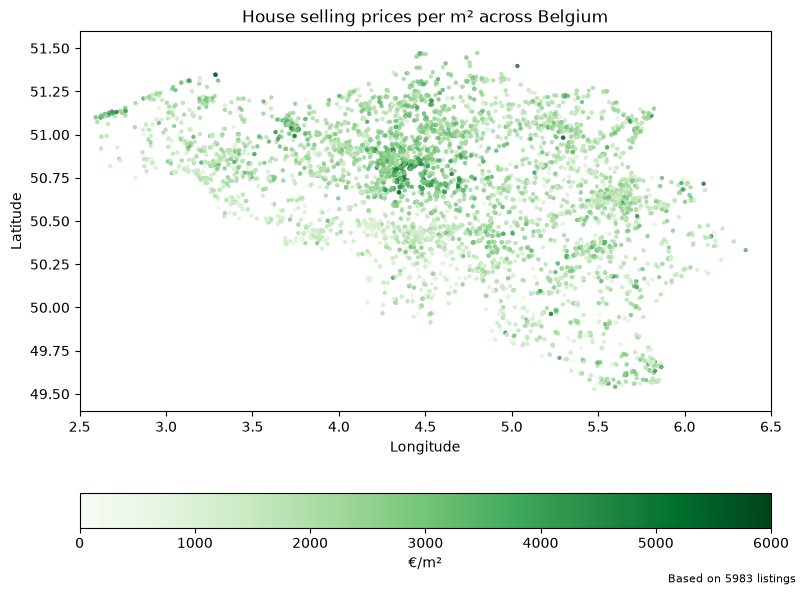

In [ ]:
# Sale - House - price per square meter 
from matplotlib.colors import Normalize
import math

# COMMON_MIN = 2000
# COMMON_MAX = 16000

df_sale_house = df_sale[df_sale["property_type"] == "House"].copy()
df_sale_house["price_per_m2"] = df_sale_house["price"] / df_sale_house["livable_surface"]

df_sale_apt = df_sale[df_sale["property_type"] == "Appartment"].copy()
df_sale_apt["price_per_m2"] = df_sale_apt["price"] / df_sale_apt["livable_surface"]

combined_price_m2 = pd.concat([
    df_sale_house["price_per_m2"],
    df_sale_apt["price_per_m2"]
]).dropna()

COMMON_MIN = math.floor(combined_price_m2.quantile(0.02) / 1000) * 1000
COMMON_MAX = math.ceil(combined_price_m2.quantile(0.98) / 1000) * 1000

norm = Normalize(vmin=COMMON_MIN, vmax=COMMON_MAX)
df_sale_house_plot = df_sale_house[
    df_sale_house["price_per_m2"].between(COMMON_MIN, COMMON_MAX)
].copy()

plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_sale_house_plot,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Greens",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=norm,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)

plt.colorbar(sm, ax=ax, label="€/m²", orientation="horizontal")
# plt.title("House selling prices per m² across Belgium")
plt.title(f"House selling prices per m² across Belgium")
plt.figtext(
    0.99,
    0.02,
    f"Based on {len(df_sale_house_plot)} listings",
    ha="right",
    fontsize=8
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


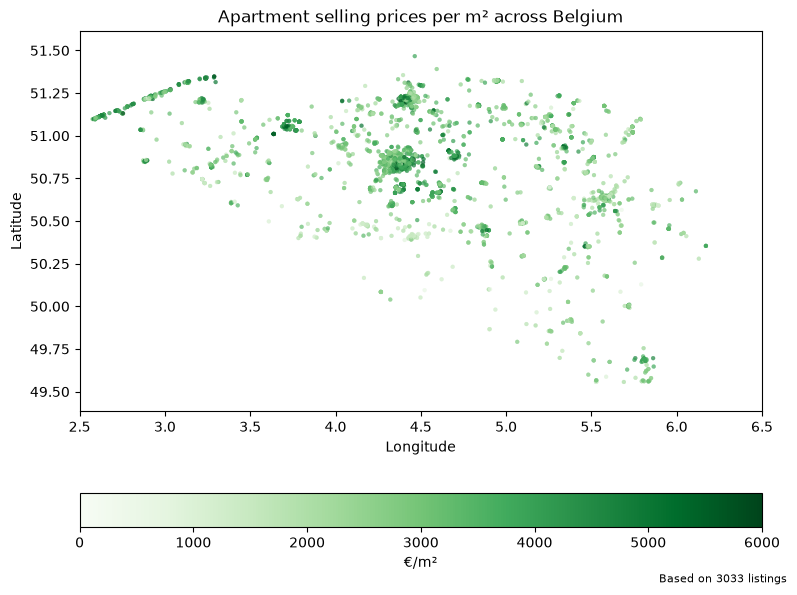

In [ ]:
# Sale - Appartment - price per square meter 

df_sale_apt_plot = df_sale_apt[
    df_sale_apt["price_per_m2"].between(COMMON_MIN, COMMON_MAX)
].copy()

plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_sale_apt_plot,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Greens",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=norm,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)

plt.colorbar(sm, ax=ax, label="€/m²", orientation="horizontal")
plt.title(f"Apartment selling prices per m² across Belgium")
plt.figtext(
    0.99,
    0.02,
    f"Based on {len(df_sale_apt_plot)} listings",
    ha="right",
    fontsize=8
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

In [ ]:
print(df_sale["property_type"].value_counts())

property_type
House         6456
Appartment    3256
Name: count, dtype: int64


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


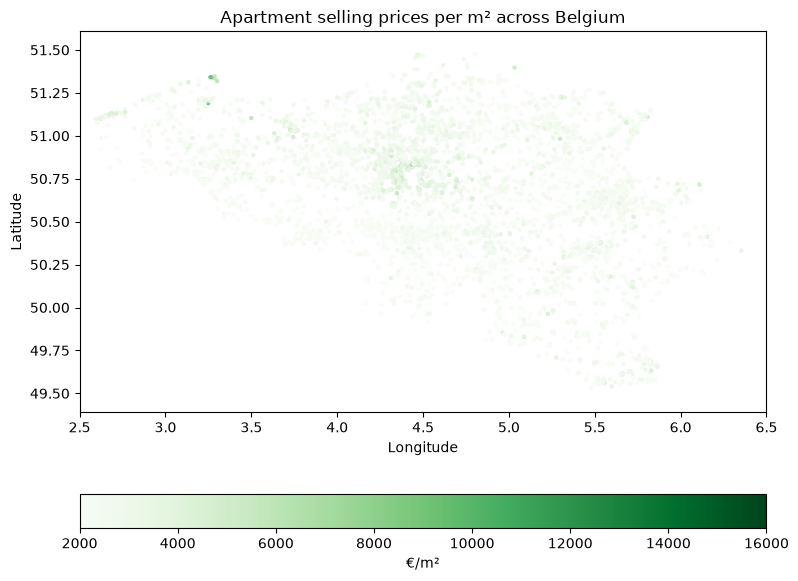

In [ ]:
# Rent - House - price per square meter 

df_sale_house = df_sale[df_sale["property_type"] == "House"].copy()
df_sale_house["price_per_m2"] = df_sale_house["price"] / df_sale_house["livable_surface"]
# min_bound = df_sale_house["price_per_m2"].quantile(0.05)
# max_bound = df_sale_house["price_per_m2"].quantile(0.95)
min_bound = COMMON_MIN
max_bound = COMMON_MAX
norm = Normalize(vmin=min_bound, vmax=max_bound)

plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_sale_house,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Greens",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=norm,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)

plt.colorbar(sm, ax=ax, label="€/m²", orientation="horizontal")
plt.title("Apartment selling prices per m² across Belgium")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


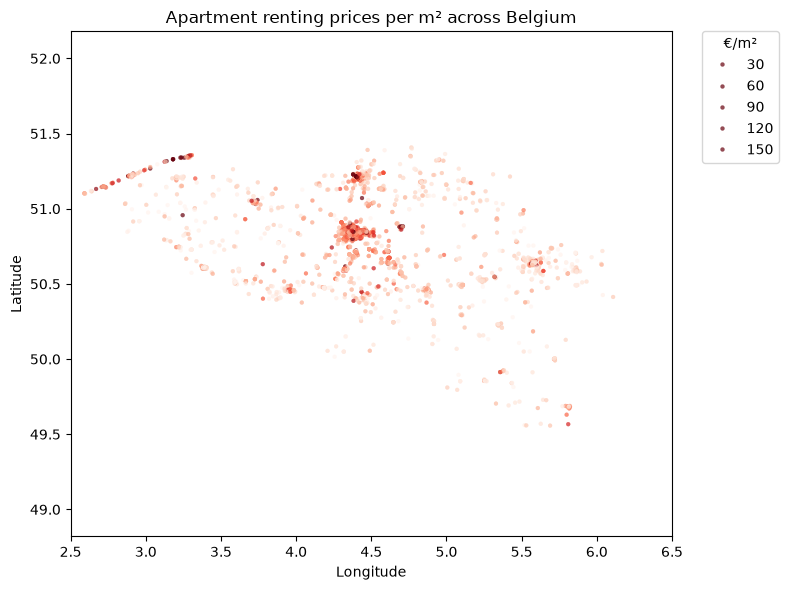

In [ ]:
# Rent - Apartment - price per square meter 

df_rent_apt = df_rent[df_rent["property_type"] == "Appartment"].copy()
df_rent_apt["price_per_m2"] = df_rent_apt["price"] / df_rent_apt["livable_surface"]
min_bound = df_rent_apt["price_per_m2"].quantile(0.05)
max_bound = df_rent_apt["price_per_m2"].quantile(0.95)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_rent_apt,
    x="longitude",
    y="latitude",
    hue="price_per_m2",
    palette="Reds",
    s=8,
    alpha=0.7,
    edgecolor=None,
    hue_norm=(min_bound, max_bound)
)

plt.title("Apartment renting prices per m² across Belgium")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="€/m²", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.axis("equal")
plt.tight_layout()
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.show()

In [ ]:
# Median value map per province

## Sale 

province_stats = (
    df_sale_house
    .groupby("province")
    .agg(
        median_price_per_m2=("price_per_m2", "median"),
        listings=("price_per_m2", "count")
    )
    .sort_values("median_price_per_m2", ascending=False)
)

print(province_stats)
province_stats["median_price_per_m2"] = province_stats["median_price_per_m2"].round(-2)

print(province_stats)

                 median_price_per_m2  listings
province                                      
Brussels                 3030.303030       181
Brabant wallon           2685.019841       628
Vlaams brabant           2619.047619       629
Antwerp                  2367.535260       450
Oost vlaanderen          2267.241379       539
West vlaanderen          2050.776144       408
Limburg                  2028.698252       538
Namur                    1950.980392       655
Luxembourg               1875.000000       655
Liège                    1799.500000       612
Hainaut                  1431.818182       713
                 median_price_per_m2  listings
province                                      
Brussels                      3000.0       181
Brabant wallon                2700.0       628
Vlaams brabant                2600.0       629
Antwerp                       2400.0       450
Oost vlaanderen               2300.0       539
West vlaanderen               2100.0       408
Limburg      

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


           province  median_price_per_m2  listings  longitude   latitude
0           Antwerp               2400.0       450   4.568365  51.170305
1    Brabant wallon               2700.0       628   4.481350  50.690861
2          Brussels               3000.0       181   4.360662  50.834020
3           Hainaut               1400.0       713   4.166667  50.454264
4           Limburg               2000.0       538   5.356443  51.027580
5             Liège               1800.0       612   5.594525  50.611578
6        Luxembourg               1900.0       655   5.514208  50.024765
7             Namur               2000.0       655   4.867048  50.311931
8   Oost vlaanderen               2300.0       539   3.889646  50.987363
9    Vlaams brabant               2600.0       629   4.386404  50.870723
10  West vlaanderen               2100.0       408   3.161276  50.954230


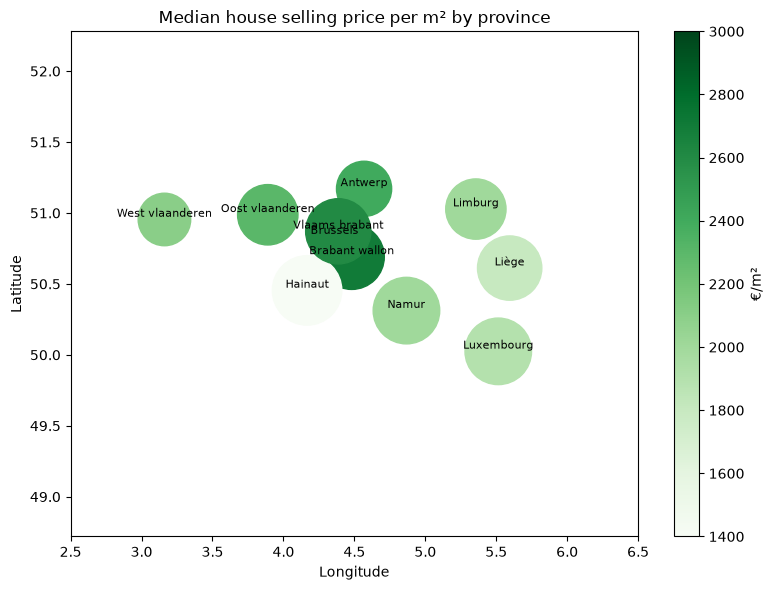

In [ ]:
# Select from df_sale_house
province_stats = (
    df_sale_house
    .groupby("province")
    .agg(
        median_price_per_m2=("price_per_m2", "median"),
        listings=("price_per_m2", "count"),
        longitude=("longitude", "median"),
        latitude=("latitude", "median")
    )
    .reset_index()
)

province_stats["median_price_per_m2"] = province_stats["median_price_per_m2"].round(-2)

print(province_stats)


province_stats["dot_size"] = (
    province_stats["listings"] / province_stats["listings"].max()
) * 2500

province_stats["dot_size"] = province_stats["dot_size"].clip(lower=200)

plt.figure(figsize=(8, 6))

# ax = sns.scatterplot(
#     data=province_stats,
#     x="longitude",
#     y="latitude",
#     hue="median_price_per_m2",
#     size="listings",
#     sizes=(80, 500),
#     palette="Greens",
#     legend=True
# )

# for _, row in province_stats.iterrows():
#     ax.text(
#         row["longitude"],
#         row["latitude"],
#         row["province"],
#         fontsize=8,
#         ha="center",
#         va="bottom"
#     )

scatter = plt.scatter(
    province_stats["longitude"],
    province_stats["latitude"],
    c=province_stats["median_price_per_m2"],
    s=province_stats["dot_size"],
    cmap="Greens"
)

plt.colorbar(scatter, label="€/m²")

for _, row in province_stats.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        row["province"],
        fontsize=8,
        ha="center",
        va="bottom"
    )

plt.title("Median house selling price per m² by province")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("equal")
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)
plt.tight_layout()
plt.show()

           province  median_price_per_m2  listings
0           Limburg               2000.0       538
1           Hainaut               1400.0       713
2   Oost vlaanderen               2300.0       539
3             Liège               1800.0       612
4        Luxembourg               1900.0       655
5    Brabant wallon               2700.0       628
6   West vlaanderen               2100.0       408
7             Namur               2000.0       655
8    Vlaams brabant               2600.0       629
9           Antwerp               2400.0       450
10         Brussels               3000.0       181


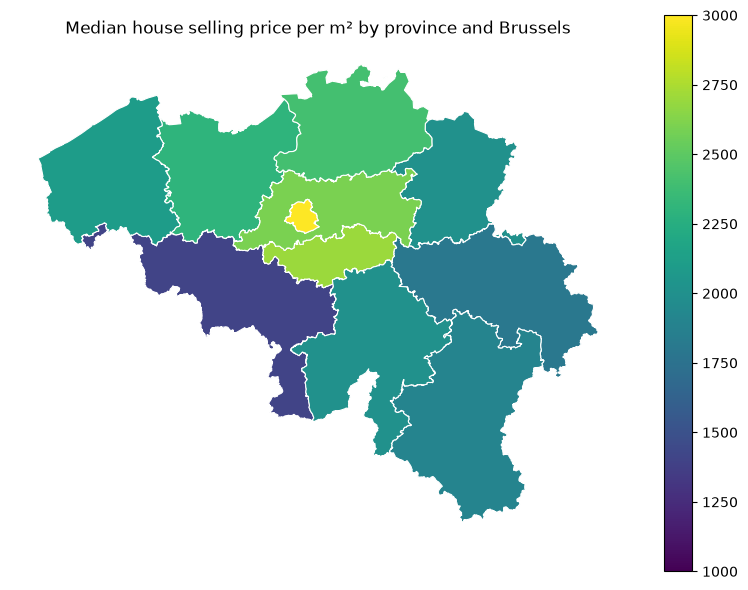

In [12]:
# Testing geopandas

import geopandas as gpd
import json
from shapely.geometry import shape

# Get the outlines for provinces
gdf_provinces = gpd.read_file("georef-belgium-province.geojson")

# Additional file for Brussels (since it's not part of provinces)
with open("georef-brussels.geojson", encoding="utf-8") as f:
    brussels_json = json.load(f)

# Get the "shape" of Brussels
brussels_shape = shape(brussels_json["features"][0])

# Add Brussels to 
gdf_brussels = gpd.GeoDataFrame(
    {"province": ["Brussels"]},
    geometry=[brussels_shape],
    crs="EPSG:4326"
)

gdf_provinces["prov_code"] = gdf_provinces["prov_code"].str[0]
code_to_province = {
    "10000": "Antwerp",
    "20001": "Vlaams brabant",
    "20002": "Brabant wallon",
    "30000": "West vlaanderen",
    "40000": "Oost vlaanderen",
    "50000": "Hainaut",
    "60000": "Liège",
    "70000": "Limburg",
    "80000": "Luxembourg",
    "90000": "Namur",
}
gdf_provinces["province"] = gdf_provinces["prov_code"].map(code_to_province)

gdf_all = pd.concat(
    [
        gdf_provinces[["province", "geometry"]],
        gdf_brussels[["province", "geometry"]]
    ],
    ignore_index=True
)

province_map = gdf_all.merge(
    province_stats,
    on="province",
    how="left"
)

print(province_map[["province", "median_price_per_m2", "listings"]])

ax = province_map.plot(
    column="median_price_per_m2",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.8,
    figsize=(8, 6),
    vmin=1000,
    vmax=3000
)

plt.title("Median house selling price per m² by province and Brussels")
plt.axis("off")
plt.tight_layout()
plt.show()